<a href="https://colab.research.google.com/github/magdoch/Bank_marketing_subscription_prediction/blob/main/HW_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%A1%D0%BE%D1%80%D0%BE%D0%BA%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.datasets import load_wine, load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px

In [2]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')

print("Розмір датасету (рядки, колонки):", df.shape)

print("\nТипи даних:")
print(df.dtypes)

print("\nЗагальна інформація:")
print(df.info())

print("\nПропущені значення по колонках:")
print(df.isnull().sum())

Розмір датасету (рядки, колонки): (2240, 29)

Типи даних:
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

Загальна інформація:
<class 

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [3]:
df[df['Income'].isnull()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,15-11-2013,11,5,...,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,20-02-2013,19,5,...,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,05-11-2013,80,81,...,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,01-01-2014,96,48,...,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,17-06-2013,57,11,...,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,14-09-2012,25,25,...,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,19-11-2012,4,230,...,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,27-05-2014,45,7,...,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,23-11-2013,87,445,...,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,11-07-2013,23,352,...,6,0,0,0,0,0,0,3,11,0


In [4]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [5]:
df['Income'].isnull().sum()

np.int64(0)

Оскільки в нас є пропущено 24 значення в колонці income то ми заповнили їх медіаною, бо вона я є менш чутливою до викидів.

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [6]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

cat_cols = sorted(cat_cols)
num_cols = sorted(num_cols)

print("Categorical columns:")
print(cat_cols)

print("\nNumerical columns:")
print(num_cols)

Categorical columns:
['Dt_Customer', 'Education', 'Marital_Status']

Numerical columns:
['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain', 'ID', 'Income', 'Kidhome', 'MntFishProducts', 'MntFruits', 'MntGoldProds', 'MntMeatProducts', 'MntSweetProducts', 'MntWines', 'NumCatalogPurchases', 'NumDealsPurchases', 'NumStorePurchases', 'NumWebPurchases', 'NumWebVisitsMonth', 'Recency', 'Response', 'Teenhome', 'Year_Birth', 'Z_CostContact', 'Z_Revenue']


In [7]:
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])

In [8]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(constant_cols)

[]


Видаляємо колонки Z_CostContact та Z_Revenue,оскільки вони не несуть для нас значення в випадку кластеризації, але може ускладнити модель.

In [9]:
print(df.columns.tolist())

['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']


In [10]:
def group_marital(status):
    if status in ['Single', 'Alone', 'YOLO', 'Absurd']:
        return 'Single'
    elif status in ['Married', 'Together']:
        return 'Partner'
    elif status in ['Divorced', 'Widow']:
        return 'Previously_married'
    else:
        return 'Other'

df['Marital_Group'] = df['Marital_Status'].apply(group_marital)

In [11]:
df = df.drop(columns=['Marital_Status'])

In [12]:
df = pd.get_dummies(df, columns=['Education', 'Marital_Group'])

In [13]:
print(df.columns.tolist())

['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Education_2n Cycle', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD', 'Marital_Group_Partner', 'Marital_Group_Previously_married', 'Marital_Group_Single']


Колонки Education та Marital_Status змінуємо завдяки One-Hot Encoding. Також ми змінили структуру Marital_Status, бо мали дуже багато різних підкатегорій, які ускладнювали нашу модель і додавали шуму.

In [14]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

# Скільки днів клієнт з компанією
df['Customer_days'] = (pd.to_datetime('today') - df['Dt_Customer']).dt.days

df['Customer_year'] = df['Dt_Customer'].dt.year
df['Customer_month'] = df['Dt_Customer'].dt.month

df = df.drop(columns=['Dt_Customer'])

Оскільки Dt_customer є дуже важливою для нас то ми робили її на три колонки відповідно, щоб могти краще проаналізувати дані.

In [15]:
df['Children'] = df['Kidhome'] + df['Teenhome']

In [16]:
df['Total_Spending'] = (
    df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
    df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
)

Обєднала колонки для того, щоб побачити кращу картину з точки зору бізнесу і не мати забагато категорій, які нам ускладнять кластеризацію.

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [17]:
df = df.drop(columns=['ID'])

In [18]:
df.dtypes

,0
Year_Birth,int64
Income,float64
Kidhome,int64
Teenhome,int64
Recency,int64
MntWines,int64
MntFruits,int64
MntMeatProducts,int64
MntFishProducts,int64
MntSweetProducts,int64


Видалили також колонку ID

In [19]:
X = df.copy()
kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)
kmeans.fit(X)

labels = kmeans.predict(X)
print(labels)

[2 0 2 ... 2 2 2]


In [20]:
centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.60


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [21]:
df['Cluster'] = labels

In [22]:
df['Total_Purchases'] = (
    df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']
)

In [23]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='Income',
    y='Total_Spending',
    z='Total_Purchases',
    color='Cluster',
    title='Customer Segments (3D)'
)

fig.show()

In [24]:
import plotly.express as px

fig = px.scatter(
    df,
    x='Income',
    y='Total_Spending',
    color='Cluster',
    size='Total_Purchases',
    title='Customer Segments'
)

fig.show()

In [45]:
df_1 = df[df['Income'] < 200000]

In [44]:
fig = px.scatter(
    df_1,
    x='Income',
    y='Total_Spending',
    color='Cluster',
    size='Total_Purchases',
    title='Customer Segments'
)

fig.show()

In [27]:
fig = px.scatter_3d(
    df_1,
    x='Income',
    y='Total_Spending',
    z='Total_Purchases',
    color='Cluster',
    title='Customer Segments (3D)'
)

fig.show()

In [28]:
fig = px.scatter(
    df,
    x='Recency',
    y='Total_Spending',
    color='Cluster',
    title='Recency vs Spending',
    opacity=0.7
)
fig.show()

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt


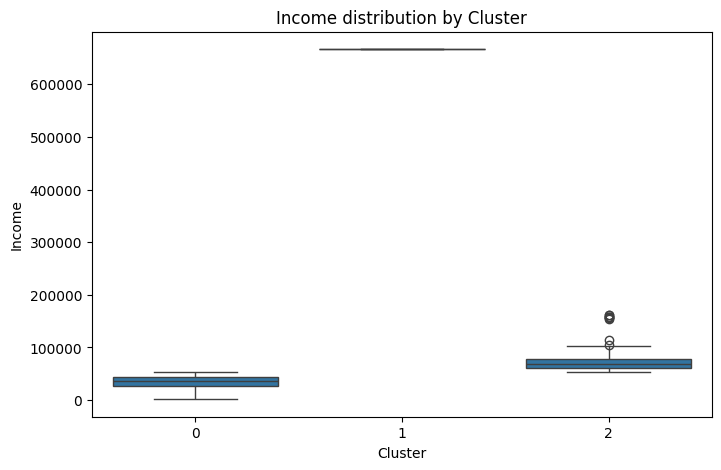

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='Income', data=df)
plt.title('Income distribution by Cluster')
plt.show()

In [31]:
fig = px.scatter(
    df,
    x='NumWebVisitsMonth',
    y='Total_Purchases',
    color='Cluster',
    title='Web Visits vs Purchases',
    opacity=0.7
)
fig.show()

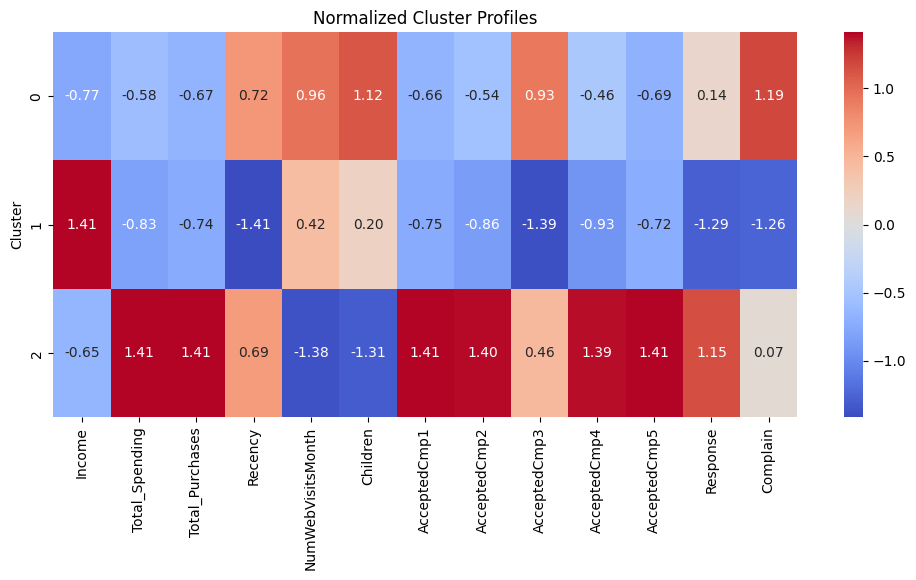

In [33]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

features_for_profile = [
    'Income',
    'Total_Spending',
    'Total_Purchases',
    'Recency',
    'NumWebVisitsMonth',
    'Children',
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5',
    'Response',
    'Complain'
]

cluster_profile = df.groupby('Cluster')[features_for_profile].mean()

scaler = StandardScaler()
cluster_profile_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_profile),
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

plt.figure(figsize=(12, 5))
sns.heatmap(
    cluster_profile_scaled,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Normalized Cluster Profiles')
plt.show()

Було виявлено, що третій кластер складається переважно з аномальних спостережень,
які мають нетипові значення доходу або витрат. Це свідчить про наявність викидів у даних, тому було прийнято рішення робитии аналіз саме на двох кластерах.
МОя heatmap показує чітке розділення між кластерами.
Перший кластер характеризується нижчим доходом, витратами та активністю покупок, але більшою кількістю веб-візитів, що може свідчити про низьку конверсію.
Другий кластер має вищий дохід, більше витрат і частіші покупки,
а також краще реагує на маркетингові кампанії.
Це дозволяє інтерпретувати його як більш цінний сегмент клієнтів.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [35]:
kmeans_scaled = KMeans(n_clusters=3, random_state=42)
labels_scaled = kmeans_scaled.fit_predict(df_scaled)

score = silhouette_score(df_scaled, labels_scaled)
print(f'Silhouette Score (scaled): {score:.3f}')


Silhouette Score (scaled): 0.137


In [36]:
features = [
    'Income',
    'Total_Spending',
    'Total_Purchases',
    'Recency',
    'NumWebVisitsMonth'
]

X = df[features]

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, labels)
print(score)

0.3029034123362059


Після масштабування всіх ознак було отримано низьке значення метрики силуету,
що свідчить про погіршення якості кластеризації. Це пов’язано з тим, що
використання великої кількості ознак, включаючи one-hot encoded змінні,
призводить до збільшення шуму та погіршення розділення кластерів.

Після відбору найбільш інформативних ознак якість кластеризації покращилась проте все одно залишається гіршою аніж без маштабування.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

В 5 завданні провела цей аналіз коли аналізувала кластери, взагальному надмірне видалення даних може презвести до збою моделі, тому я орієнтувалася саме на Income і Total spending. В нас дуже багато даних, які як створюють шум так і можуть давати викривлення моделі, тому я обрала орієнтуватися на значущі дані.

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

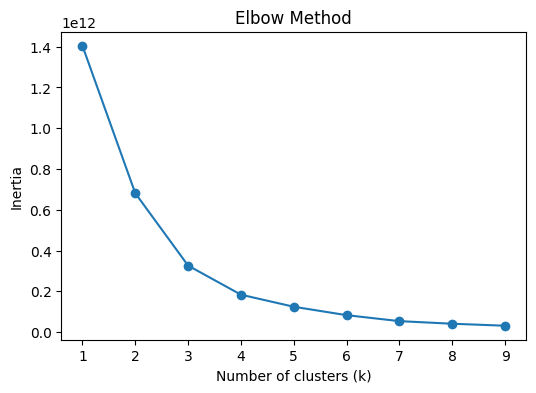

In [40]:
inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [41]:
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f'k={k}: Silhouette={score:.3f}')

k=2: Silhouette=0.960
k=3: Silhouette=0.598
k=4: Silhouette=0.544


In [42]:
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f'k={k}: Silhouette={score:.3f}')

k=2: Silhouette=0.402
k=3: Silhouette=0.303
k=4: Silhouette=0.263


In [43]:
k_opt = 2

kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

df['Cluster'] = labels.astype(str)

In [46]:
fig = px.scatter(
    df,
    x='Income',
    y='Total_Spending',
    color='Cluster',
    size='Total_Purchases',
    title='Customer Segments (no scaling)',
    opacity=0.7
)

fig.show()

In [47]:
fig = px.scatter_3d(
    df,
    x='Income',
    y='Total_Spending',
    z='Total_Purchases',
    color='Cluster',
    title='3D Customer Segments (no scaling)',
    opacity=0.7
)

fig.show()

In [48]:
df.groupby('Cluster')[[
    'Income',
    'Total_Spending',
    'Total_Purchases',
    'Recency',
    'NumWebVisitsMonth'
]].mean()

,Income,Total_Spending,Total_Purchases,Recency,NumWebVisitsMonth
Cluster,,,,,
0,35303.774874,179.041315,7.475548,49.349073,6.605396
1,71292.967742,1086.000949,18.232448,48.839658,3.866224


Було виявлено два основних сегменти клієнтів.
Перший кластер характеризується нижчим доходом, низьким рівнем витрат
та меншою кількістю покупок, але при цьому має вищу кількість відвідувань
вебсайту. Це може свідчити про низьку конверсію.
Другий кластер має значно вищий дохід, витрати та кількість покупок,
що дозволяє інтерпретувати його як основний сегмент високої цінності.
Цікаво, що клієнти з нижчим доходом частіше відвідують сайт, але рідше
здійснюють покупки, що може бути сигналом для оптимізації маркетингових
та дизайн-рішень.

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [50]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [58]:
features = [
    'Income',
    'Total_Spending',
    'Total_Purchases',
    'Recency',
    'NumWebVisitsMonth'
]

df_hc = df[df['Income'] < 150000].copy()
X_hc = df_hc[features]

dist_sin = linkage(X_hc, method='single')

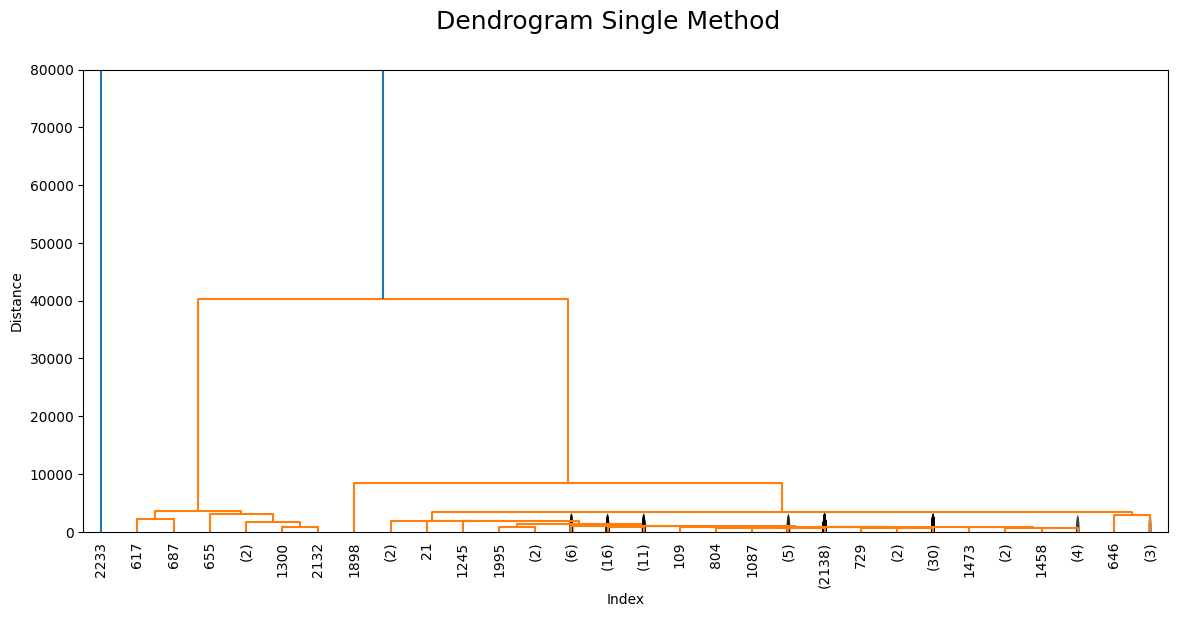

In [65]:
plt.figure(figsize=(14,6))

dendrogram(
    dist_sin,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.ylim(0, 80000)

plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle('Dendrogram Single Method', fontsize=18)
plt.show()

In [89]:
df_hc = df[df['Income'] < 150000].copy()
X_hc = df_hc[features]

dist_sin = linkage(X_hc, method='single')

In [90]:
clusters_2 = fcluster(dist_sin, t=2, criterion='maxclust')
df_hc['HC_Cluster_2'] = clusters_2.astype(str)

clusters_3 = fcluster(dist_sin, t=3, criterion='maxclust')
df_hc['HC_Cluster_3'] = clusters_3.astype(str)

In [91]:
print(len(df_hc))
print(len(X_hc))
print(len(clusters_2))
print(len(clusters_3))

2232
2232
2232
2232


In [76]:
score_2 = silhouette_score(X_hc, clusters_2)
score_3 = silhouette_score(X_hc, clusters_3)

print(f'Silhouette (2 clusters): {score_2:.3f}')
print(f'Silhouette (3 clusters): {score_3:.3f}')

Silhouette (2 clusters): 0.557
Silhouette (3 clusters): 0.450


In [73]:
import plotly.express as px


In [78]:
fig = px.scatter(
    df_hc,
    x='Income',
    y='Total_Spending',
    color='HC_Cluster_2',
    size='Total_Purchases',
    title='Hierarchical Clustering (2 clusters)',
    opacity=0.7
)

fig.show()

In [79]:
fig = px.scatter(
    df_hc,
    x='Income',
    y='Total_Spending',
    color='HC_Cluster_3',
    size='Total_Purchases',
    title='Hierarchical Clustering: 3 clusters',
    opacity=0.7
)

fig.show()

In [80]:
df_hc.groupby('HC_Cluster_2')[[
    'Income','Total_Spending','Total_Purchases','Recency','NumWebVisitsMonth'
]].mean()

,Income,Total_Spending,Total_Purchases,Recency,NumWebVisitsMonth
HC_Cluster_2,,,,,
1,51603.090542,605.743613,12.535634,49.12909,5.333483
2,113734.000000,277.000000,27.000000,9.00000,1.000000


In [81]:
df_hc.groupby('HC_Cluster_3')[[
    'Income','Total_Spending','Total_Purchases','Recency','NumWebVisitsMonth'
]].mean()

,Income,Total_Spending,Total_Purchases,Recency,NumWebVisitsMonth
HC_Cluster_3,,,,,
1,51510.643018,604.491693,12.508307,49.143691,5.338123
2,103073.250000,1302.750000,27.750000,41.000000,2.750000
3,113734.000000,277.000000,27.000000,9.000000,1.000000



Було побудовано плоскі кластеризації на 2 та 3 кластери на основі
ієрархічного методу single linkage. Метрика силуету для цього методу є низькою, що свідчить про
погану якість кластеризації.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [88]:
df_db = df[df['Income'] < 150000].copy()
X_db = df_db[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_db)

In [92]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.8, min_samples=10)
labels = model.fit_predict(X_scaled)

df_db['DBSCAN_Cluster'] = labels.astype(str)

In [93]:
df_db['DBSCAN_Cluster'].value_counts()

,count
DBSCAN_Cluster,
0,2136
-1,96


Бачимо зразу наші викиди.

In [97]:
for eps in [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]:
    model = DBSCAN(eps=eps, min_samples=10)
    labels = model.fit_predict(X_scaled)

    print(f"\neps = {eps}")
    print(pd.Series(labels).value_counts().sort_index())

    mask = labels != -1
    n_clusters = len(set(labels[mask]))

    if n_clusters > 1:
        score = silhouette_score(X_scaled[mask], labels[mask])
        print(f"Silhouette: {score:.3f}")
    else:
        print("Silhouette cannot be calculated: only 1 cluster")


eps = 0.5
-1    1049
 0    1031
 1      10
 2      35
 3      39
 4      10
 5      15
 6      10
 7      12
 8       9
 9      12
Name: count, dtype: int64
Silhouette: 0.183

eps = 0.8
-1      96
 0    2136
Name: count, dtype: int64
Silhouette cannot be calculated: only 1 cluster

eps = 1.0
-1      21
 0    2211
Name: count, dtype: int64
Silhouette cannot be calculated: only 1 cluster

eps = 1.2
-1      14
 0    2218
Name: count, dtype: int64
Silhouette cannot be calculated: only 1 cluster

eps = 1.5
-1      14
 0    2218
Name: count, dtype: int64
Silhouette cannot be calculated: only 1 cluster

eps = 2.0
-1       8
 0    2224
Name: count, dtype: int64
Silhouette cannot be calculated: only 1 cluster


Було застосовано метод кластеризації DBSCAN з різними значеннями параметра eps.

При малих значеннях eps (0.5) алгоритм виділяє велику кількість дрібних кластерів
та значну кількість шумових спостережень. Метрика силуету є низькою, що свідчить
про слабке розділення кластерів.

При більших значеннях eps алгоритм об’єднує майже всі спостереження в один кластер,
що робить неможливим використання метрики силуету.

In [98]:
model = DBSCAN(eps=0.5, min_samples=10)
labels_db = model.fit_predict(X_scaled)

df_db['DBSCAN_Cluster'] = labels_db.astype(str)

print(df_db['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
-1    1049
0     1031
3       39
2       35
5       15
9       12
7       12
6       10
1       10
4       10
8        9
Name: count, dtype: int64


In [99]:
mask = labels_db != -1
n_clusters = len(set(labels_db[mask]))

if n_clusters > 1:
    score_db = silhouette_score(X_scaled[mask], labels_db[mask])
    print(f"Final DBSCAN Silhouette: {score_db:.3f}")
else:
    print("Silhouette cannot be calculated: only 1 cluster after excluding noise")

Final DBSCAN Silhouette: 0.183


Метод DBSCAN показав низьку якість кластеризації (приблизно 0.18),
що свідчить про слабке розділення кластерів.
При різних значеннях параметра eps алгоритм або формує велику кількість
дрібних кластерів та шуму, або об’єднує всі точки в один кластер.

In [102]:
from sklearn.cluster import AgglomerativeClustering


In [103]:
df_alt = df[df['Income'] < 150000].copy()
X_alt = df_alt[features]

In [104]:
model = AgglomerativeClustering(
    n_clusters=2,
    linkage='complete'
)

labels = model.fit_predict(X_alt)

df_alt['Agg_Cluster'] = labels.astype(str)

In [105]:
score = silhouette_score(X_alt, labels)
print(f"Silhouette score (Agglomerative - complete): {score:.3f}")

Silhouette score (Agglomerative - complete): 0.595


In [106]:
fig = px.scatter(
    df_alt,
    x='Income',
    y='Total_Spending',
    color='Agg_Cluster',
    size='Total_Purchases',
    title='Agglomerative Clustering (Complete Linkage)',
    opacity=0.7
)

fig.show()

У порівнянні з KMeans, метод Agglomerative Clustering (complete linkage)
дав дуже подібний результат, виділивши ті ж два основні сегменти клієнтів.
Обидва методи показали хорошу якість кластеризації, що підтверджується
метрикою силуету.